In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_xgb.pkl
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/X_test.parquet
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_cat.pkl
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/submission_cat.csv
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_rf.pkl
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/submission_mlp.csv
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/X_train_cat.parquet
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/y_train.parquet
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/X_train.parquet
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_lgb.pkl
/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_rf.pkl
/kaggle/input/models/davibaca

In [2]:
!pip install -U optuna
import optuna
print(optuna.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.1.0
    Uninstalling optuna-4.1.0:
      Successfully uninstalled optuna-4.1.0
4.9.0


In [3]:
!pip install -U scikit-learn
import sklearn
print(sklearn.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 58.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
1.7.2


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()

In [5]:
# Create functions

# Time series features
def create_features(df):
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df


In [6]:
# DataFrame with training data
train_df = pd.read_csv('/kaggle/input/playground-series-s5e1/train.csv', parse_dates=["date"])
train_df.head()

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [7]:
# DataFrame with testing data
test_df = pd.read_csv('/kaggle/input/playground-series-s5e1/test.csv',parse_dates=["date"])
test_df.head()


,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


# Data analysis

In [8]:
#Type of variables
train_df.dtypes

id                   int64
date        datetime64[ns]
country             object
store               object
product             object
num_sold           float64
dtype: object

Three variables type object, one type date time. Dependent variable type numeric

In [9]:
train_df["country"].value_counts()

country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
Name: count, dtype: int64

In [10]:
train_df.groupby('country')['num_sold'].sum()

country
Canada       28653095.0
Finland      28698872.0
Italy        20797669.0
Kenya          689141.0
Norway       54562305.0
Singapore    33102374.0
Name: num_sold, dtype: float64

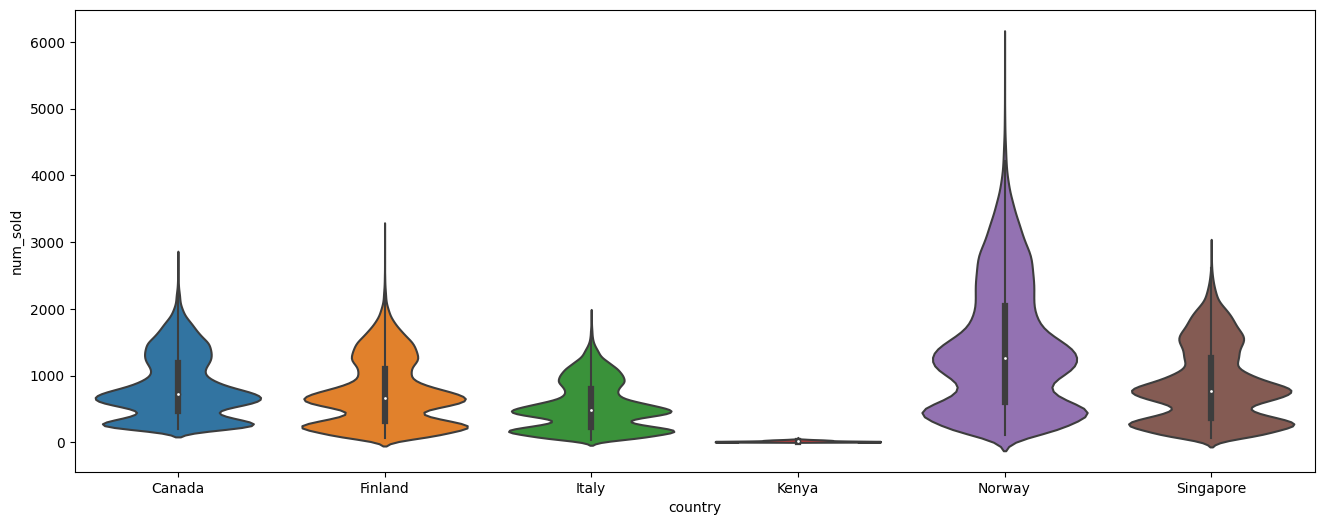

In [11]:
plt.figure(figsize=(16, 6))

sns.violinplot(x='country', y='num_sold', data=train_df, scale='width')

plt.show()

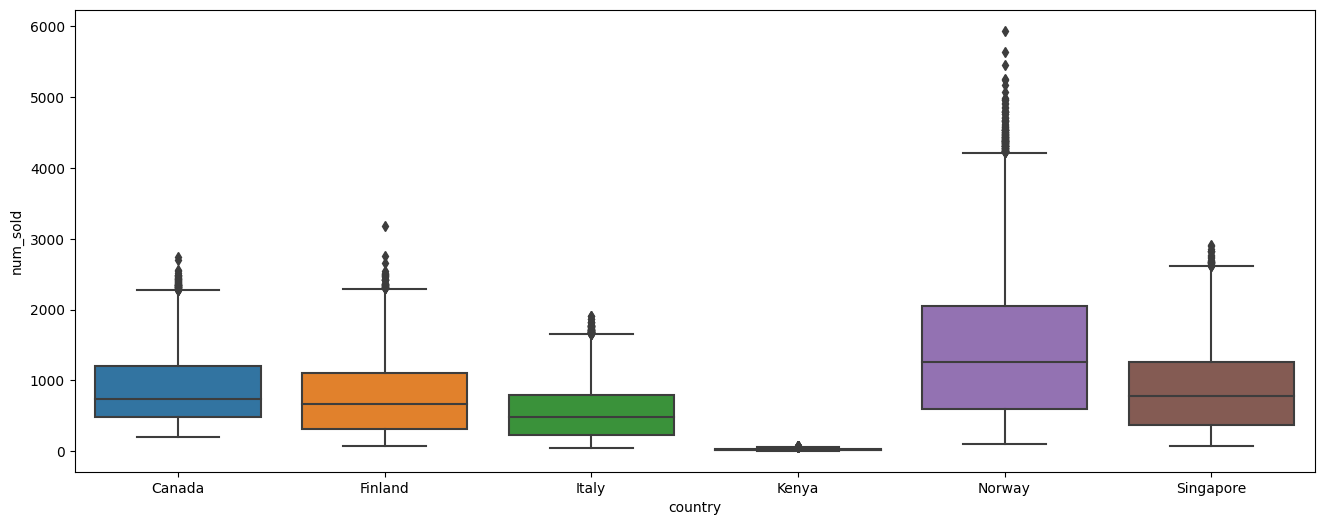

In [12]:
plt.figure(figsize=(16, 6))

sns.boxplot(x='country', y='num_sold', data=train_df)

plt.show()

In [13]:
train_df["store"].value_counts()

store
Discount Stickers       76710
Stickers for Less       76710
Premium Sticker Mart    76710
Name: count, dtype: int64

In [14]:
train_df.groupby('store')['num_sold'].sum()

store
Discount Stickers       30599237.0
Premium Sticker Mart    73703822.0
Stickers for Less       62200397.0
Name: num_sold, dtype: float64

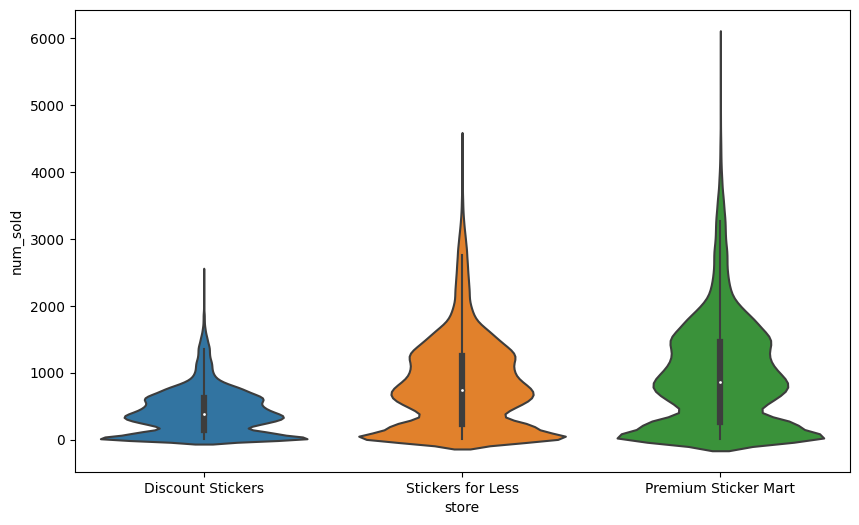

In [15]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='store', y='num_sold', data=train_df, scale='width')

plt.show()

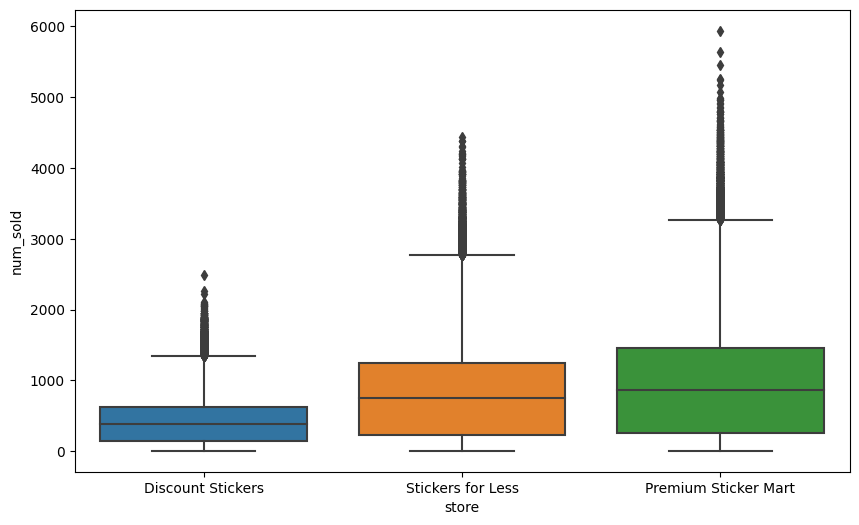

In [16]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='store', y='num_sold', data=train_df)

plt.show()

In [17]:
train_df["product"].value_counts()

product
Holographic Goose     46026
Kaggle                46026
Kaggle Tiers          46026
Kerneler              46026
Kerneler Dark Mode    46026
Name: count, dtype: int64

In [18]:
train_df.groupby('product')['num_sold'].sum()

product
Holographic Goose      7350368.0
Kaggle                56721733.0
Kaggle Tiers          46870306.0
Kerneler              25596840.0
Kerneler Dark Mode    29964209.0
Name: num_sold, dtype: float64

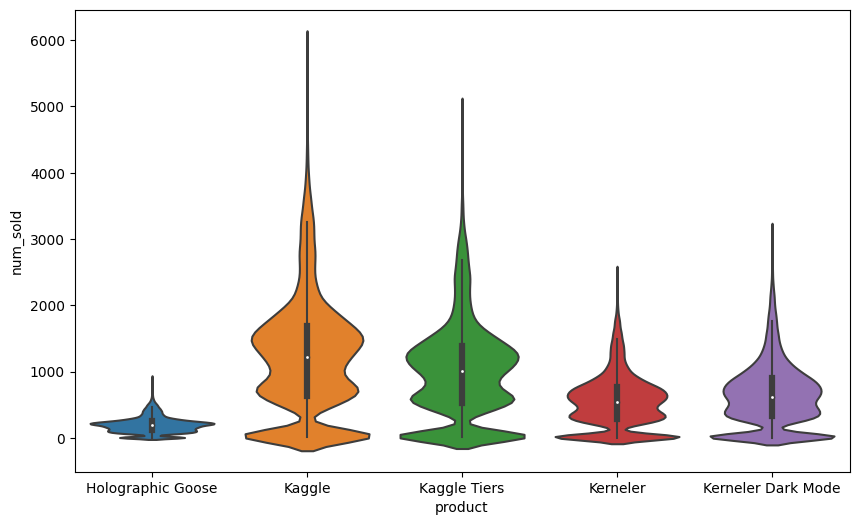

In [19]:
plt.figure(figsize=(10, 6))

sns.violinplot(x='product', y='num_sold', data=train_df, scale='width')

plt.show()

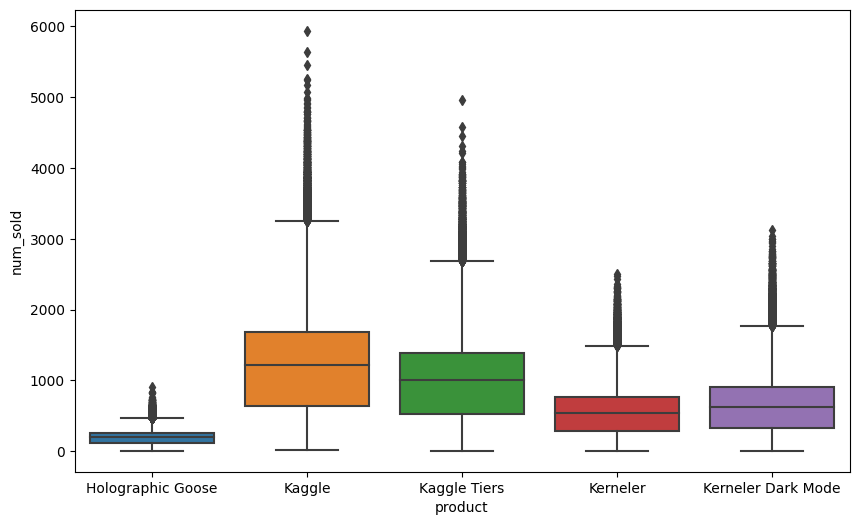

In [20]:
plt.figure(figsize=(10, 6))

sns.boxplot(x='product', y='num_sold', data=train_df)

plt.show()

The variables country, store and product are categorical nominal variables.

The variable country has 6 levels, store has 3 levels and product has 5 levels

# NAs

<Axes: xlabel='product', ylabel='country'>

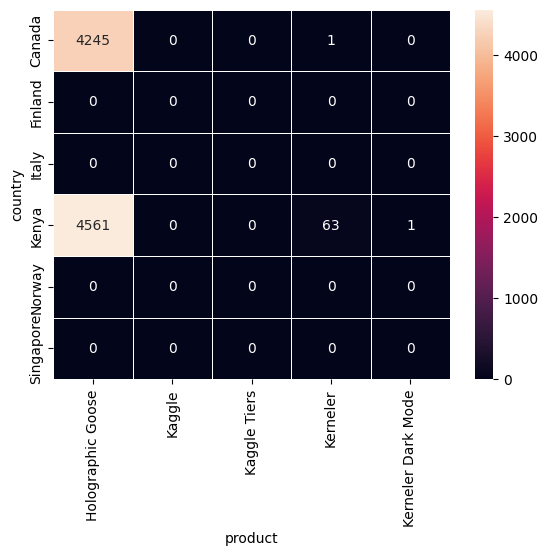

In [21]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='store', ylabel='country'>

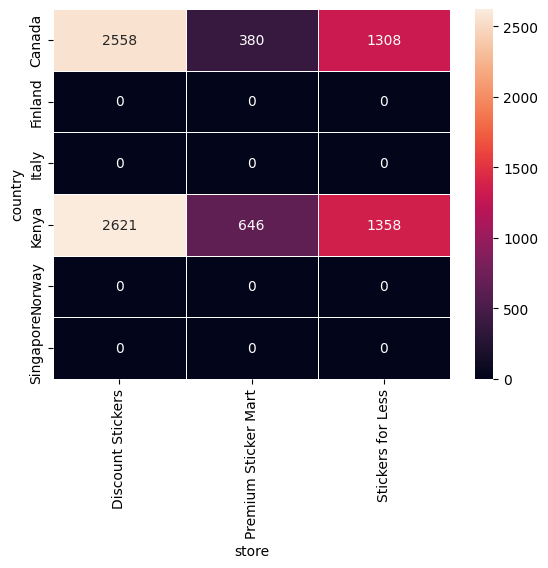

In [22]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['store'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


<Axes: xlabel='product', ylabel='store'>

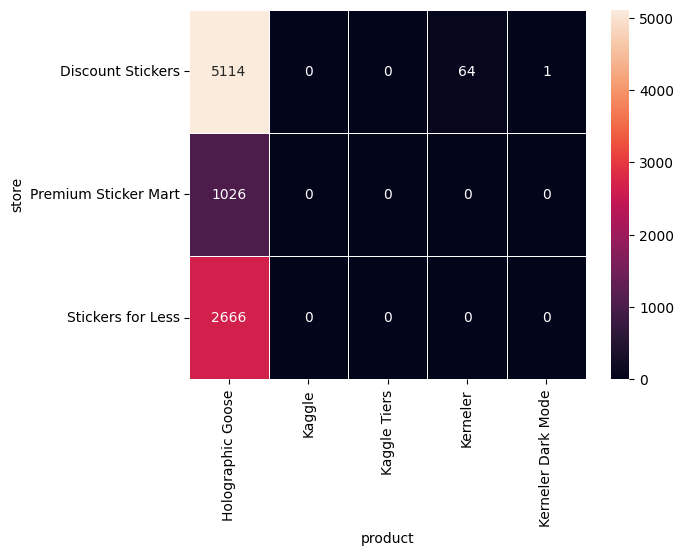

In [23]:
nas_matrix = pd.crosstab(
    index=train_df['store'],
    columns=train_df['product'],  
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)


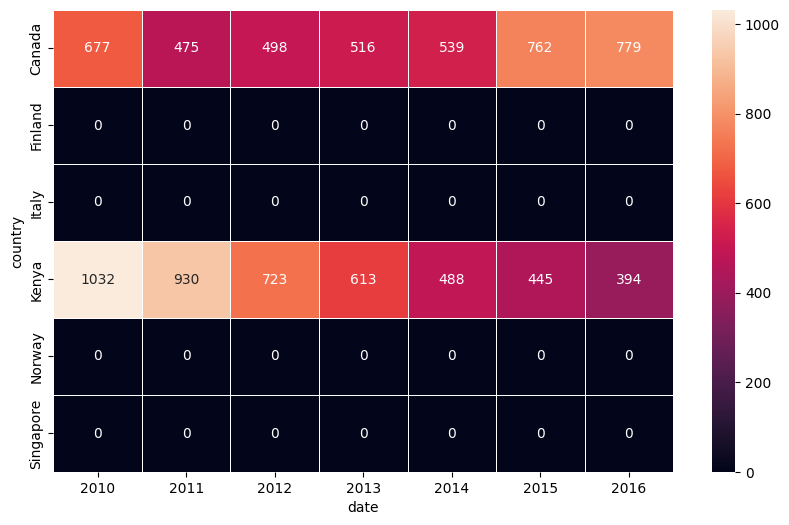

In [24]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.year,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(10, 6))

sns.heatmap(
    nas_matrix,
    annot=True,
    fmt='g',
    linewidths=0.5,
)
plt.show()

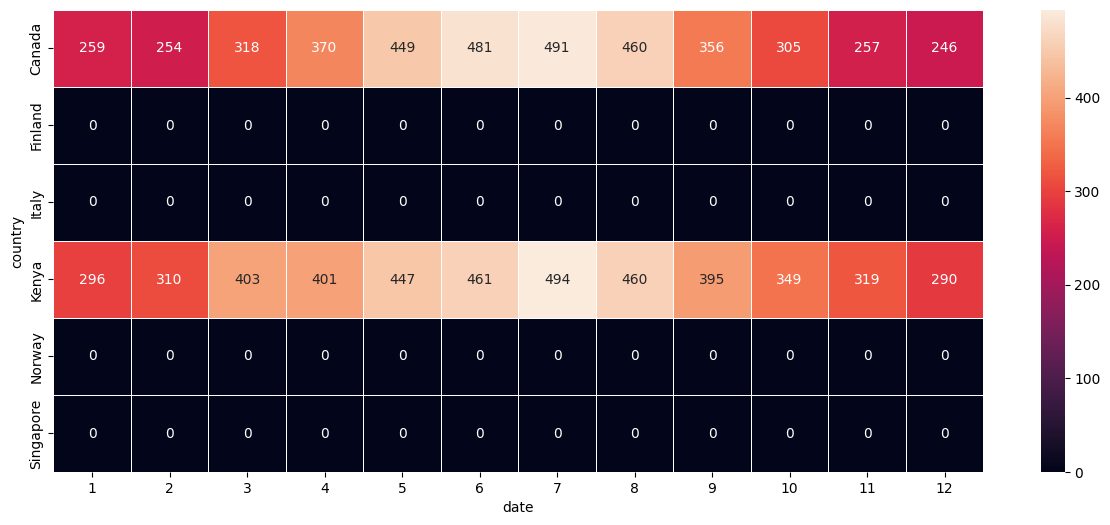

In [25]:
nas_matrix = pd.crosstab(
    index=train_df['country'],
    columns=train_df['date'].dt.month,
    values=train_df['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)
plt.figure(figsize=(15, 6))
sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)
plt.show()

It seems that there is a patron in the data loss Canda and Kenya had lost the same product (holographic goose). The store which had lost more data is Discount Stickers followed by Stickers for Less and Premium Sticker Mart. There also seems to be a patron with year, where first years of data get more lost.

We are going to look closer to Canada and Kenya

In [26]:
df_Canada = train_df[train_df['country']=='Canada'].copy()
df_Kenya = train_df[train_df['country']=='Kenya'].copy()

<Axes: xlabel='product', ylabel='store'>

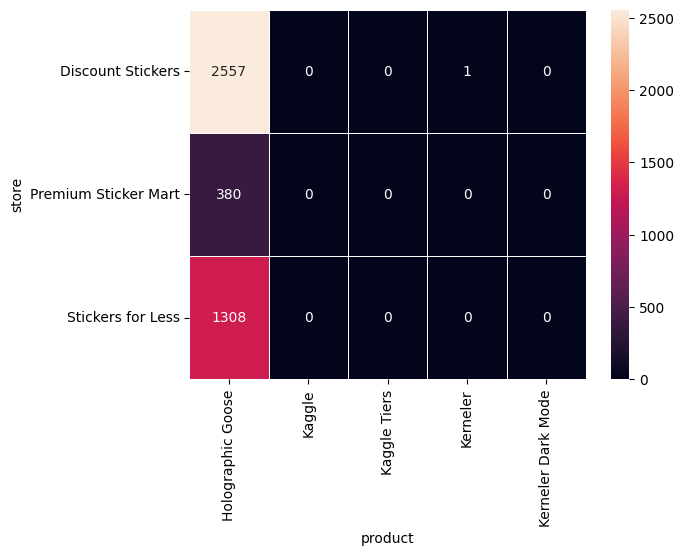

In [27]:
nas_matrix = pd.crosstab(
    index=df_Canada['store'],
    columns=df_Canada['product'],  
    values=df_Canada['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

<Axes: xlabel='product', ylabel='store'>

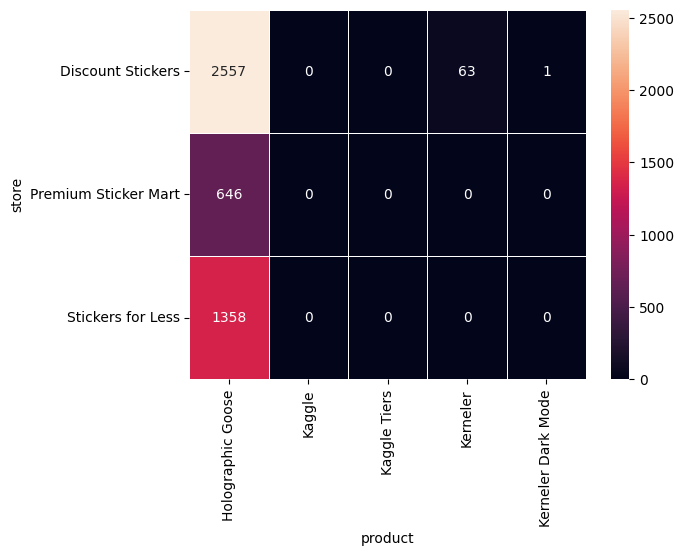

In [28]:
nas_matrix = pd.crosstab(
    index=df_Kenya['store'],
    columns=df_Kenya['product'],  
    values=df_Kenya['num_sold'].isna(), 
    aggfunc='sum', 
).fillna(0)

sns.heatmap(
    nas_matrix,
    annot=True,  
    fmt='g',
    linewidths=0.5,
)

In [29]:
group_means = train_df.groupby(['product', 'country','store'])['num_sold'].mean().to_dict()
group_means

{('Holographic Goose', 'Canada', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 248.3821773082223,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 228.8166533226581,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 98.00156433320298,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 235.26046147829487,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 198.95580758701604,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 70.84630426280798,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 170.38287055142746,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 144.0183809151349,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): nan,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 5.941915227629513,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 5.470391993327773,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 186.7258506061791,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart

In [30]:
count_grupo = train_df.groupby(['product', 'country','store'])['num_sold'].count().to_dict()
count_grupo

{('Holographic Goose', 'Canada', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Canada', 'Premium Sticker Mart'): 2177,
 ('Holographic Goose', 'Canada', 'Stickers for Less'): 1249,
 ('Holographic Goose', 'Finland', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Finland', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Finland', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Italy', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Italy', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Italy', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Kenya', 'Discount Stickers'): 0,
 ('Holographic Goose', 'Kenya', 'Premium Sticker Mart'): 1911,
 ('Holographic Goose', 'Kenya', 'Stickers for Less'): 1199,
 ('Holographic Goose', 'Norway', 'Discount Stickers'): 2557,
 ('Holographic Goose', 'Norway', 'Premium Sticker Mart'): 2557,
 ('Holographic Goose', 'Norway', 'Stickers for Less'): 2557,
 ('Holographic Goose', 'Singapore', 'Discount Stickers'): 2557,
 ('Holographic 

In [31]:
zero_df = (train_df['num_sold']==0).sum()
zero_df

0

There are two groups with no means. meaning there is no value. Probably the NAs are 0 due to the fact that there is not 0 value. So we are going to imputate with 0

In [32]:
train_df.duplicated().sum()

0

In [33]:
# Solve the NAs problems on X data
train_df_without_na=train_df.fillna(0)

# Outliers

<Axes: ylabel='num_sold'>

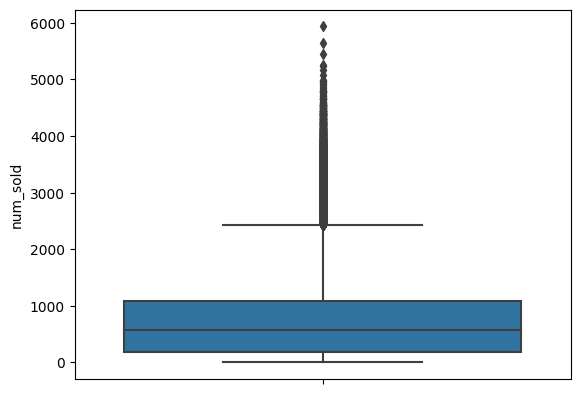

In [34]:
sns.boxplot(data=train_df_without_na, y="num_sold")

# DATA transformation

In [35]:
#Create a new column to differentiate the two dataFrame and join them
train_df_without_na['isFuture'] = False
test_df['isFuture'] = True
df_merged = pd.concat([train_df_without_na, test_df])
df_merged = df_merged.reset_index(drop=True)
#add a time-step feature 
df_merged = df_merged.sort_values(['country', 'store', 'product', 'date'])
df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() 

#Use the function create_features to get time features
df_merged = create_features(df_merged)

df_merged

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pan

,id,date,country,store,product,num_sold,isFuture,Time,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,0.0,False,0,4,1,1,2010,1,1,53
90,90,2010-01-02,Canada,Discount Stickers,Holographic Goose,0.0,False,1,5,1,1,2010,2,2,53
180,180,2010-01-03,Canada,Discount Stickers,Holographic Goose,0.0,False,2,6,1,1,2010,3,3,53
270,270,2010-01-04,Canada,Discount Stickers,Holographic Goose,0.0,False,3,0,1,1,2010,4,4,1
360,360,2010-01-05,Canada,Discount Stickers,Holographic Goose,0.0,False,4,1,1,1,2010,5,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328314,328314,2019-12-27,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3647,4,4,12,2019,361,27,52
328404,328404,2019-12-28,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3648,5,4,12,2019,362,28,52
328494,328494,2019-12-29,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3649,6,4,12,2019,363,29,52
328584,328584,2019-12-30,Singapore,Stickers for Less,Kerneler Dark Mode,NaN,True,3650,0,4,12,2019,364,30,1


In [36]:
# see new dataframe columns
df_merged.columns

Index(['id', 'date', 'country', 'store', 'product', 'num_sold', 'isFuture',
       'Time', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear',
       'dayofmonth', 'weekofyear'],
      dtype='object')

In [37]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['isFuture']==False].num_sold


train_df_features = ['id','isFuture','country', 'store',
                     'product','Time',
                     'dayofweek', 'quarter',
                     'month','year', 'dayofyear',
                     'dayofmonth','weekofyear']

df_x = df_merged[train_df_features].copy()

In [38]:
# See which columns are type categorical and store them
s = (df_x.dtypes == 'object')
object_cols = list(s[s].index)
print(f"Categorical variables:\n{object_cols}")

Categorical variables:
['country', 'store', 'product']


In [39]:
#Transforming the categorical variables from the test and training data into numerical
import sklearn
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, feature_name_combiner='concat')
OH_array  = OH_encoder.fit_transform(df_x[object_cols])
OH_cols_df = pd.DataFrame(OH_array, columns=OH_encoder.get_feature_names_out(object_cols), index=df_x.index
)
OH_cols_df

,country_Canada,country_Finland,country_Italy,country_Kenya,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328675,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
328676,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
328677,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
328678,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [40]:
#Merge the categorical variables with the other variables
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)

OH_x_df.columns

Index(['id', 'isFuture', 'Time', 'dayofweek', 'quarter', 'month', 'year',
       'dayofyear', 'dayofmonth', 'weekofyear', 'country_Canada',
       'country_Finland', 'country_Italy', 'country_Kenya', 'country_Norway',
       'country_Singapore', 'store_Discount Stickers',
       'store_Premium Sticker Mart', 'store_Stickers for Less',
       'product_Holographic Goose', 'product_Kaggle', 'product_Kaggle Tiers',
       'product_Kerneler', 'product_Kerneler Dark Mode'],
      dtype='object')

In [41]:
#Make sure there isn't no NAs
print(f"NAs num_sold: {y_train.isnull().sum()} \n\n NAs varialbes: \n{OH_x_df.isnull().sum()}")


NAs num_sold: 0 

 NAs varialbes: 
id                            0
isFuture                      0
Time                          0
dayofweek                     0
quarter                       0
month                         0
year                          0
dayofyear                     0
dayofmonth                    0
weekofyear                    0
country_Canada                0
country_Finland               0
country_Italy                 0
country_Kenya                 0
country_Norway                0
country_Singapore             0
store_Discount Stickers       0
store_Premium Sticker Mart    0
store_Stickers for Less       0
product_Holographic Goose     0
product_Kaggle                0
product_Kaggle Tiers          0
product_Kerneler              0
product_Kerneler Dark Mode    0
dtype: int64


In [42]:
#Separate the test data and training data
X_train = OH_x_df[OH_x_df['isFuture']==False].drop(['id', 'isFuture'], axis=1).copy()
X_test = OH_x_df[OH_x_df['isFuture']==True].drop(['id', 'isFuture'], axis=1).copy()

In [43]:
#Separate the test data and training data for CatBoost model
X_train_cat = df_x[df_x['isFuture']==False].drop(['id', 'isFuture'], axis=1).copy()
X_test_cat = df_x[df_x['isFuture']==True].drop(['id', 'isFuture'], axis=1).copy()

In [44]:
import joblib
import json
import optuna
import optuna.visualization as vis
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from optuna.pruners import MedianPruner
from functools import partial

# Kaggle directory for saving files
Output_directory= '/kaggle/working/'
#Kaggle directory for loading files
Input_directory = '/kaggle/input/datasets/davibaca/study-v1/'
Input_directory_v2 = '/kaggle/input/datasets/davibaca/study-v2/'

# Save dataframes

X_train.to_parquet(f'{Output_directory}X_train.parquet')
X_test.to_parquet(f'{Output_directory}X_test.parquet')
X_train_cat.to_parquet(f'{Output_directory}X_train_cat.parquet')
X_test_cat.to_parquet(f'{Output_directory}X_test_cat.parquet')
y_train.to_frame(name='sales').to_parquet(f'{Output_directory}y_train.parquet')

# Time-based validation: respects chronological order, never validates on data prior to that fold's train set
tscv = TimeSeriesSplit(n_splits=5)

# Pruner
pruner = MedianPruner(
    n_startup_trials=8,
    n_warmup_steps=2,
    interval_steps=1,
    n_min_trials=8,
)

# Early stopping: stops the whole study if the best value hasn't improved in the last `patience` trials
def early_stopping(study, trial, patience=30, start_trial_number=0):
    trials_since_start = trial.number - start_trial_number
    if trials_since_start < patience:
        return

    best_trial_number = study.best_trial.number
    if best_trial_number < start_trial_number:
        trials_without_improvement = trials_since_start
    else:
        trials_without_improvement = trial.number - best_trial_number

    if trials_without_improvement >= patience:
        print(f"No improvement in the last {patience} trials. Stopping study.")
        study.stop()
#Sampler with seed for every model
sampler= optuna.samplers.TPESampler(seed=42)

In [45]:
##############################################################
# 1. XGBoost
##############################################################
def objective_xgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_xgb = optuna.create_study(sampler=sampler,direction='minimize', pruner=pruner)
#study_xgb.optimize(objective_xgb, n_trials=100, callbacks=[partial(early_stopping, patience=30)])
#print(f"XGBoost best parameters: {study_xgb.best_params}")

#Load study
study_xgb = joblib.load(f'{Input_directory}study_xgb.pkl')
# saves the study
#joblib.dump(study_xgb, f'{Output_directory}study_xgb.pkl')

In [46]:
print(f"Trials executed: {len(study_xgb.trials)}")
print(f"Best trial: {study_xgb.best_trial.number}")
print(f"Best RMSE: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

Trials executed: 100
Best trial: 73
Best RMSE: 104.5370
Best parameters: {'n_estimators': 755, 'max_depth': 7, 'learning_rate': 0.01849521361291576, 'subsample': 0.7409812717286525, 'colsample_bytree': 0.6283021270436713, 'reg_alpha': 0.002547454465767703, 'reg_lambda': 0.7693848929700662}


In [47]:
df_trials_xgb = study_xgb.trials_dataframe()
print(df_trials_xgb[['number', 'value','state']].tail(15))

    number       value     state
85      85  105.846591  COMPLETE
86      86  104.773443  COMPLETE
87      87  106.178436    PRUNED
88      88  105.923955  COMPLETE
89      89  105.198983  COMPLETE
90      90  105.788255    PRUNED
91      91  104.927702  COMPLETE
92      92  104.677596  COMPLETE
93      93  105.905627  COMPLETE
94      94  105.580836  COMPLETE
95      95  105.209033  COMPLETE
96      96  105.469322    PRUNED
97      97  105.143194  COMPLETE
98      98  106.024006  COMPLETE
99      99  107.481390    PRUNED


In [48]:
vis.plot_optimization_history(study_xgb).show()
vis.plot_param_importances(study_xgb).show()

In [49]:
##############################################################
# 1. XGBoost
##############################################################
def objective_xgb_v2(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#start_trial_number = len(study_xgb.trials)
#study_xgb.optimize(objective_xgb_v2, n_trials=100, callbacks=[partial(early_stopping, patience=30, start_trial_number=start_trial_number)])
#print(f"XGBoost best parameters: {study_xgb.best_params}")

# saves the study
#joblib.dump(study_xgb, f'{Output_directory}study_xgb_v2.pkl')
# Load study 
study_xgb_v2 = joblib.load(f'{Input_directory_v2}study_xgb_v2.pkl')

In [50]:
print(f"Trials executed: {len(study_xgb_v2.trials)}")
print(f"Best trial: {study_xgb_v2.best_trial.number}")
print(f"Best RMSE: {study_xgb_v2.best_value:.4f}")
print(f"Best parameters: {study_xgb_v2.best_params}")

Trials executed: 160
Best trial: 129
Best RMSE: 104.4342
Best parameters: {'n_estimators': 695, 'max_depth': 7, 'learning_rate': 0.020479852557329904, 'subsample': 0.725967121673761, 'colsample_bytree': 0.6036625564790362, 'reg_alpha': 0.0017914814532766158, 'reg_lambda': 0.11256377839132521}


In [51]:
df_trials_xgb_v2 = study_xgb_v2.trials_dataframe()
print(df_trials_xgb_v2[['number', 'value','state']].tail(15))

     number       value     state
145     145  106.543815    PRUNED
146     146  105.890167  COMPLETE
147     147  104.972461  COMPLETE
148     148  106.281452    PRUNED
149     149  454.708681    PRUNED
150     150  105.701345  COMPLETE
151     151  104.907016  COMPLETE
152     152  104.872710  COMPLETE
153     153  104.378818    PRUNED
154     154  105.481859  COMPLETE
155     155  104.609199  COMPLETE
156     156  105.350724  COMPLETE
157     157  105.418417  COMPLETE
158     158  106.317984  COMPLETE
159     159  104.732510    PRUNED


In [52]:
vis.plot_optimization_history(study_xgb_v2).show()
vis.plot_param_importances(study_xgb_v2).show()

In [53]:
##############################################################
# 2. Random Forest
##############################################################
def objective_rf(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_scores)

#study_rf = optuna.create_study(sampler=sampler, direction='minimize', pruner=pruner)
#study_rf.optimize(objective_rf, n_trials=100, callbacks=[partial(early_stopping, patience=30)])
#print(f"Random Forest best parameters: {study_rf.best_params}")

# saves the study
#joblib.dump(study_rf, f'{Output_directory}study_rf.pkl')
# Load study 
study_rf = joblib.load(f'{Input_directory}study_rf.pkl')

In [54]:
print(f"Trials executed: {len(study_rf.trials)}")
print(f"Best trial: {study_rf.best_trial.number}")
print(f"Best RMSE: {study_rf.best_value:.4f}")
print(f"Best parameters: {study_rf.best_params}")

Trials executed: 94
Best trial: 63
Best RMSE: 114.1684
Best parameters: {'n_estimators': 104, 'max_depth': 17, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': None}


In [55]:
df_trials_rf = study_rf.trials_dataframe()
print(df_trials_rf[['number', 'value','state']].tail(15))

    number       value     state
79      79  114.300071  COMPLETE
80      80  114.301414  COMPLETE
81      81  116.833230    PRUNED
82      82  116.736303    PRUNED
83      83  116.495502    PRUNED
84      84  116.779925    PRUNED
85      85  114.445689  COMPLETE
86      86  114.245957  COMPLETE
87      87  116.564457    PRUNED
88      88  121.586995    PRUNED
89      89  116.466781    PRUNED
90      90  116.768015    PRUNED
91      91  114.338771  COMPLETE
92      92  114.299620  COMPLETE
93      93  114.242774  COMPLETE


In [56]:
vis.plot_optimization_history(study_rf).show()
vis.plot_param_importances(study_rf).show()

In [57]:
##############################################################
# 2. Random Forest
##############################################################
def objective_rf_v2(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = RandomForestRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return np.mean(fold_scores)
#start_trial_number = len(study_rf.trials)
#study_rf.optimize(objective_rf_v2, n_trials=100, callbacks=[partial(early_stopping, patience=30, start_trial_number=start_trial_number)])
#print(f"Random Forest best parameters: {study_rf.best_params}")

# saves the study
#joblib.dump(study_rf, f'{Output_directory}study_rf_v2.pkl')
# Load study 
study_rf_v2 = joblib.load(f'{Input_directory_v2}study_rf_v2.pkl')

In [58]:
print(f"Trials executed: {len(study_rf_v2.trials)}")
print(f"Best trial: {study_rf_v2.best_trial.number}")
print(f"Best RMSE: {study_rf_v2.best_value:.4f}")
print(f"Best parameters: {study_rf_v2.best_params}")

Trials executed: 153
Best trial: 122
Best RMSE: 114.0250
Best parameters: {'n_estimators': 167, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None}


In [59]:
df_trials_rf_v2 = study_rf_v2.trials_dataframe()
print(df_trials_rf_v2[['number', 'value','state']].tail(15))

     number       value     state
138     138  114.206573  COMPLETE
139     139  116.701180    PRUNED
140     140  114.208093  COMPLETE
141     141  114.179106  COMPLETE
142     142  114.179729  COMPLETE
143     143  116.440944    PRUNED
144     144  114.170064  COMPLETE
145     145  114.103479  COMPLETE
146     146  119.761886    PRUNED
147     147  114.214126  COMPLETE
148     148  114.120267  COMPLETE
149     149  114.087576  COMPLETE
150     150  117.456403    PRUNED
151     151  114.082430  COMPLETE
152     152  114.097745  COMPLETE


In [60]:
vis.plot_optimization_history(study_rf_v2).show()
vis.plot_param_importances(study_rf_v2).show()

In [61]:
##############################################################
# 3. LightGBM
##############################################################
def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbosity': -1,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_lgb = optuna.create_study(sampler=sampler, direction='minimize', pruner=pruner)
#study_lgb.optimize(objective_lgb, n_trials=100, callbacks=[partial(early_stopping, patience=30)])
#print(f"LightGBM best parameters: {study_lgb.best_params}")

# saves the study
#joblib.dump(study_lgb, f'{Output_directory}study_lgb.pkl')
#Load study
study_lgb = joblib.load(f'{Input_directory}study_lgb.pkl')

In [62]:
print(f"Trials executed: {len(study_lgb.trials)}")
print(f"Best trial: {study_lgb.best_trial.number}")
print(f"Best RMSE: {study_lgb.best_value:.4f}")
print(f"Best parameters: {study_lgb.best_params}")

Trials executed: 65
Best trial: 34
Best RMSE: 104.0072
Best parameters: {'n_estimators': 293, 'max_depth': 10, 'num_leaves': 58, 'learning_rate': 0.13362102477410304, 'subsample': 0.6742366805498864, 'colsample_bytree': 0.6041883910975827, 'reg_alpha': 0.6637803838710051, 'reg_lambda': 3.5010462632102807e-07}


In [63]:
df_trials_lgb = study_lgb.trials_dataframe()
print(df_trials_lgb[['number', 'value','state']].tail(15))

    number       value     state
50      50  106.241514  COMPLETE
51      51  105.098931  COMPLETE
52      52  104.624738  COMPLETE
53      53  104.801227  COMPLETE
54      54  128.051074    PRUNED
55      55  107.559543  COMPLETE
56      56  107.517374  COMPLETE
57      57  105.924864  COMPLETE
58      58  145.596716    PRUNED
59      59  105.243281  COMPLETE
60      60  104.816278  COMPLETE
61      61  105.293243  COMPLETE
62      62  104.292293  COMPLETE
63      63  107.041499    PRUNED
64      64  107.539054    PRUNED


In [64]:
vis.plot_optimization_history(study_lgb).show()
vis.plot_param_importances(study_lgb).show()

In [65]:
##############################################################
# 4. CatBoost
##############################################################
def objective_cat(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': False,
        'cat_features': object_cols,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_cat)):
        X_tr, X_va = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


#study_cat = optuna.create_study(sampler=sampler, direction='minimize', pruner=pruner)
#study_cat.optimize(objective_cat, n_trials=100, callbacks=[partial(early_stopping, patience=30)])
#print(f"CatBoost best parameters: {study_cat.best_params}")

# saves the study
#joblib.dump(study_cat, f'{Output_directory}study_cat.pkl')
#Load study 
study_cat = joblib.load(f'{Input_directory}study_cat.pkl')

In [66]:
print(f"Trials executed: {len(study_cat.trials)}")
print(f"Best trial: {study_cat.best_trial.number}")
print(f"Best RMSE: {study_cat.best_value:.4f}")
print(f"Best parameters: {study_cat.best_params}")

Trials executed: 64
Best trial: 33
Best RMSE: 109.8650
Best parameters: {'iterations': 659, 'depth': 6, 'learning_rate': 0.09810919871718651, 'l2_leaf_reg': 0.005228780831439912, 'random_strength': 2.7026465355795297e-07}


In [67]:
df_trials_cat = study_cat.trials_dataframe()
print(df_trials_cat[['number', 'value','state']].tail(15))

    number       value     state
49      49  112.390911  COMPLETE
50      50  112.534373    PRUNED
51      51  110.751048  COMPLETE
52      52  110.470842  COMPLETE
53      53  115.613853    PRUNED
54      54  111.760900  COMPLETE
55      55  112.213464  COMPLETE
56      56  115.089098  COMPLETE
57      57  116.986291    PRUNED
58      58  112.444077  COMPLETE
59      59  112.836598  COMPLETE
60      60  115.261593  COMPLETE
61      61  110.489537  COMPLETE
62      62  110.179299  COMPLETE
63      63  116.220095  COMPLETE


In [68]:
vis.plot_optimization_history(study_cat).show()
vis.plot_param_importances(study_cat).show()

In [69]:
##############################################################
# 4. CatBoost
##############################################################
def objective_cat_v2(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-10, 10.0, log=True),
        'random_state': 42,
        'verbose': False,
        'cat_features': object_cols,
    }
    
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_cat)):
        X_tr, X_va = X_train_cat.iloc[train_idx], X_train_cat.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = CatBoostRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#start_trial_number = len(study_cat.trials)
#study_cat.optimize(objective_cat_v2, n_trials=100, callbacks=[partial(early_stopping, patience=30,  start_trial_number=start_trial_number)])
#print(f"CatBoost best parameters: {study_cat.best_params}")

# saves the study
#joblib.dump(study_cat, f'{Output_directory}study_cat_v2.pkl')

#Load study 
study_cat_v2 = joblib.load(f'{Input_directory_v2}study_cat_v2.pkl')

In [70]:
print(f"Trials executed: {len(study_cat_v2.trials)}")
print(f"Best trial: {study_cat_v2.best_trial.number}")
print(f"Best RMSE: {study_cat_v2.best_value:.4f}")
print(f"Best parameters: {study_cat_v2.best_params}")

Trials executed: 107
Best trial: 76
Best RMSE: 109.4742
Best parameters: {'iterations': 747, 'depth': 5, 'learning_rate': 0.11818439524867903, 'l2_leaf_reg': 2.704656255715955e-08, 'random_strength': 3.7381318032571706}


In [71]:
df_trials_cat_v2 = study_cat_v2.trials_dataframe()
print(df_trials_cat_v2[['number', 'value','state']].tail(15))

     number       value     state
92       92  111.888130  COMPLETE
93       93  112.025846  COMPLETE
94       94  111.566724  COMPLETE
95       95  110.820765  COMPLETE
96       96  115.780596  COMPLETE
97       97  112.127406  COMPLETE
98       98  112.853690  COMPLETE
99       99  111.814891  COMPLETE
100     100  110.681975  COMPLETE
101     101  111.923232  COMPLETE
102     102  112.238971  COMPLETE
103     103  111.394765  COMPLETE
104     104  110.467204  COMPLETE
105     105  110.503092  COMPLETE
106     106  111.442802  COMPLETE


In [72]:
vis.plot_optimization_history(study_cat_v2).show()
vis.plot_param_importances(study_cat_v2).show()

In [73]:
##############################################################
# 5. Gradient Boosting 
##############################################################
def objective_gb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = GradientBoostingRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


#study_gb = optuna.create_study(sampler=sampler, direction='minimize', pruner=pruner)
#study_gb.optimize(objective_gb, n_trials=180, callbacks=[partial(early_stopping, patience=60)])
#print(f"Gradient Boosting best parameters: {study_gb.best_params}")

# saves the study
#joblib.dump(study_gb, f'{Output_directory}study_gb.pkl')
#Load study 
study_gb = joblib.load(f'{Input_directory}study_gb.pkl')

In [74]:
print(f"Trials executed: {len(study_gb.trials)}")
print(f"Best trial: {study_gb.best_trial.number}")
print(f"Best RMSE: {study_gb.best_value:.4f}")
print(f"Best parameters: {study_gb.best_params}")

Trials executed: 40
Best trial: 9
Best RMSE: 106.6083
Best parameters: {'n_estimators': 696, 'max_depth': 4, 'learning_rate': 0.05864129169696527, 'subsample': 0.8186841117373118, 'min_samples_leaf': 2}


In [75]:
df_trials_gb = study_gb.trials_dataframe()
print(df_trials_gb[['number', 'value','state']].tail(15))

    number       value     state
25      25  109.570614  COMPLETE
26      26  199.812487    PRUNED
27      27  108.921789  COMPLETE
28      28  114.323271    PRUNED
29      29  123.166492    PRUNED
30      30  114.018141    PRUNED
31      31  106.957513  COMPLETE
32      32  107.965914  COMPLETE
33      33  108.140957  COMPLETE
34      34  149.017496    PRUNED
35      35  110.547854    PRUNED
36      36  118.377670    PRUNED
37      37  106.977505  COMPLETE
38      38  107.507733  COMPLETE
39      39  110.666769    PRUNED


In [76]:
vis.plot_optimization_history(study_gb).show()
vis.plot_param_importances(study_gb).show()

In [77]:
##############################################################
# 5. Gradient Boosting 
##############################################################
def objective_gb_v2(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = GradientBoostingRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)


#start_trial_number = len(study_gb.trials)
#study_gb.optimize(objective_gb_v2, n_trials=130, callbacks=[partial(early_stopping, patience=40,  start_trial_number=start_trial_number)])
#print(f"Gradient Boosting best parameters: {study_gb.best_params}")

# saves the study
#joblib.dump(study_gb, f'{Output_directory}study_gb_v2.pkl')

#Load study 
study_gb_v2 = joblib.load(f'{Input_directory_v2}study_gb_v2.pkl')

In [78]:
print(f"Trials executed: {len(study_gb_v2.trials)}")
print(f"Best trial: {study_gb_v2.best_trial.number}")
print(f"Best RMSE: {study_gb_v2.best_value:.4f}")
print(f"Best parameters: {study_gb_v2.best_params}")

Trials executed: 104
Best trial: 63
Best RMSE: 105.0411
Best parameters: {'n_estimators': 481, 'max_depth': 4, 'learning_rate': 0.10791961621446577, 'subsample': 0.940371979794377, 'min_samples_leaf': 8}


In [79]:
df_trials_gb_v2 = study_gb_v2.trials_dataframe()
print(df_trials_gb_v2[['number', 'value','state']].tail(15))

     number       value     state
89       89  111.894674    PRUNED
90       90  108.099564  COMPLETE
91       91  109.820469    PRUNED
92       92  113.294128    PRUNED
93       93  112.159534    PRUNED
94       94  110.332561    PRUNED
95       95  110.179555    PRUNED
96       96  110.882133    PRUNED
97       97  109.964937    PRUNED
98       98  111.269804    PRUNED
99       99  109.483006    PRUNED
100     100  110.800104    PRUNED
101     101  110.253562    PRUNED
102     102  106.248046  COMPLETE
103     103  116.475202    PRUNED


In [80]:
vis.plot_optimization_history(study_gb_v2).show()
vis.plot_param_importances(study_gb_v2).show()

In [81]:
##############################################################
# 6. Extra Trees
##############################################################
def objective_et(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = ExtraTreesRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#study_et = optuna.create_study(sampler=sampler, direction='minimize', pruner=pruner)
#study_et.optimize(objective_et, n_trials=100, callbacks=[partial(early_stopping, patience=30)])
#print(f"Extra Trees best parameters: {study_et.best_params}")

# saves the study
#joblib.dump(study_et, f'{Output_directory}study_et.pkl')

#Load data
study_et = joblib.load(f'{Input_directory}study_et.pkl')

In [82]:
print(f"Trials executed: {len(study_et.trials)}")
print(f"Best trial: {study_et.best_trial.number}")
print(f"Best RMSE: {study_et.best_value:.4f}")
print(f"Best parameters: {study_et.best_params}")

Trials executed: 100
Best trial: 76
Best RMSE: 116.8217
Best parameters: {'n_estimators': 368, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None}


In [83]:
df_trials_et = study_et.trials_dataframe()
print(df_trials_et[['number', 'value','state']].tail(15))

    number       value     state
85      85  116.988794  COMPLETE
86      86  115.966124    PRUNED
87      87  129.731653    PRUNED
88      88  116.121309    PRUNED
89      89  116.779348    PRUNED
90      90  116.948593  COMPLETE
91      91  116.906060  COMPLETE
92      92  116.953822  COMPLETE
93      93  116.949358  COMPLETE
94      94  116.951340  COMPLETE
95      95  116.952996  COMPLETE
96      96  116.942571  COMPLETE
97      97  116.945083  COMPLETE
98      98  128.477650    PRUNED
99      99  116.197121    PRUNED


In [84]:
vis.plot_optimization_history(study_et).show()
vis.plot_param_importances(study_et).show()

In [85]:
##############################################################
# 6. Extra Trees
##############################################################
def objective_et_v2(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42,
        'n_jobs': -1,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = ExtraTreesRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

#start_trial_number = len(study_et.trials)
#study_et.optimize(objective_et_v2, n_trials=100, callbacks=[partial(early_stopping, patience=30,  start_trial_number=start_trial_number)])
#print(f"Extra Trees best parameters: {study_et.best_params}")

# saves the study
#joblib.dump(study_et, f'{Output_directory}study_et_v2.pkl')

#Load study 
study_et_v2 = joblib.load(f'{Input_directory_v2}study_et_v2.pkl')

In [86]:
print(f"Trials executed: {len(study_et_v2.trials)}")
print(f"Best trial: {study_et_v2.best_trial.number}")
print(f"Best RMSE: {study_et_v2.best_value:.4f}")
print(f"Best parameters: {study_et_v2.best_params}")

Trials executed: 131
Best trial: 76
Best RMSE: 116.8217
Best parameters: {'n_estimators': 368, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None}


In [87]:
df_trials_et_v2 = study_et_v2.trials_dataframe()
print(df_trials_et_v2[['number', 'value','state']].tail(15))

     number       value     state
116     116  116.286272    PRUNED
117     117  117.113014  COMPLETE
118     118  116.010990    PRUNED
119     119  116.591065    PRUNED
120     120  125.468069    PRUNED
121     121  116.946293  COMPLETE
122     122  116.951122  COMPLETE
123     123  116.990745  COMPLETE
124     124  117.070235  COMPLETE
125     125  115.877366    PRUNED
126     126  116.241490    PRUNED
127     127  116.164702    PRUNED
128     128  129.433691    PRUNED
129     129  116.937667  COMPLETE
130     130  115.949800    PRUNED


In [88]:
vis.plot_optimization_history(study_et_v2).show()
vis.plot_param_importances(study_et_v2).show()

In [89]:
##############################################################
# Final comparison
##############################################################
print("\n--- RMSE Summary (lower is better) ---")
print(f"XGBoost:           {study_xgb_v2.best_value:.4f}")
print(f"Random Forest:      {study_rf_v2.best_value:.4f}")
print(f"LightGBM:           {study_lgb.best_value:.4f}")
print(f"CatBoost:           {study_cat_v2.best_value:.4f}")
print(f"Gradient Boosting:  {study_gb_v2.best_value:.4f}")
print(f"Extra Trees:        {study_et_v2.best_value:.4f}")


--- RMSE Summary (lower is better) ---
XGBoost:           104.4342
Random Forest:      114.0250
LightGBM:           104.0072
CatBoost:           109.4742
Gradient Boosting:  105.0411
Extra Trees:        116.8217


In [90]:
# 1. LightGBM
# model_lgb = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42, verbosity=-1)
# model_lgb.fit(X_train, y_train)
# joblib.dump(model_lgb, f'{Output_directory}model_lgb.pkl')
model_lgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_lgb.pkl')
# pred_val_lgb = model_lgb.predict(X_test)
# joblib.dump(pred_val_lgb, f'{Output_directory}pred_val_lgb.pkl')
pred_val_lgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_lgb.pkl')

# 2. XGBoost
# model_xgb = xgb.XGBRegressor(**study_xgb_v2.best_params, random_state=42)
# model_xgb.fit(X_train, y_train)
# joblib.dump(model_xgb, f'{Output_directory}model_xgb.pkl')
model_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_xgb.pkl')
# pred_val_xgb = model_xgb.predict(X_test)
# joblib.dump(pred_val_xgb, f'{Output_directory}pred_val_xgb.pkl')
pred_val_xgb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_xgb.pkl')

# 3. Gradient Boosting
# model_gb = GradientBoostingRegressor(**study_gb_v2.best_params, random_state=42)
# model_gb.fit(X_train, y_train)
# joblib.dump(model_gb, f'{Output_directory}model_gb.pkl')
model_gb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_gb.pkl')
# pred_val_gb = model_gb.predict(X_test)
# joblib.dump(pred_val_gb, f'{Output_directory}pred_val_gb.pkl')
pred_val_gb = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_gb.pkl')

# 4. CatBoost 
# model_cat = CatBoostRegressor(**study_cat_v2.best_params, random_state=42, verbose=False, cat_features=object_cols)
# model_cat.fit(X_train_cat, y_train)
# joblib.dump(model_cat, f'{Output_directory}model_cat.pkl')
model_cat = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_cat.pkl')
# pred_val_cat = model_cat.predict(X_test_cat)
# joblib.dump(pred_val_cat, f'{Output_directory}pred_val_cat.pkl')
pred_val_cat = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_cat.pkl')


# 5. Random Forest
# model_rf = RandomForestRegressor(**study_rf_v2.best_params, random_state=42, n_jobs=-1)
# model_rf.fit(X_train, y_train)
# joblib.dump(model_rf, f'{Output_directory}model_rf.pkl')
model_rf = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_rf.pkl')
# pred_val_rf = model_rf.predict(X_test)
# joblib.dump(pred_val_rf, f'{Output_directory}pred_val_rf.pkl')
pred_val_rf = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_rf.pkl')

# 6. Extra Trees
# model_et = ExtraTreesRegressor(**study_et_v2.best_params, random_state=42, n_jobs=-1)
# model_et.fit(X_train, y_train)
# joblib.dump(model_et, f'{Output_directory}model_et.pkl')
model_et = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/model_et.pkl')
# pred_val_et = model_et.predict(X_test)
# joblib.dump(pred_val_et, f'{Output_directory}pred_val_et.pkl')
pred_val_et = joblib.load('/kaggle/input/models/davibaca/models-and-predictions-v1/keras/default/1/pred_val_et.pkl')


In [91]:
id_test = test_df['id'].values
# submission_lgb = pd.DataFrame({'id': id_test, 'num_sold': pred_val_lgb})
# submission_lgb.to_csv(f'{Output_directory}submission_lgb.csv', index=False)

# submission_xgb = pd.DataFrame({'id': id_test, 'num_sold': pred_val_xgb})
# submission_xgb.to_csv(f'{Output_directory}submission_xgb.csv', index=False)

# submission_gb = pd.DataFrame({'id': id_test, 'num_sold': pred_val_gb})
# submission_gb.to_csv(f'{Output_directory}submission_gb.csv', index=False)

# submission_cat = pd.DataFrame({'id': id_test, 'num_sold': pred_val_cat})
# submission_cat.to_csv(f'{Output_directory}submission_cat.csv', index=False)

# submission_rf = pd.DataFrame({'id': id_test, 'num_sold': pred_val_rf})
# submission_rf.to_csv(f'{Output_directory}submission_rf.csv', index=False)

# submission_et = pd.DataFrame({'id': id_test, 'num_sold': pred_val_et})
# submission_et.to_csv(f'{Output_directory}submission_et.csv', index=False)


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

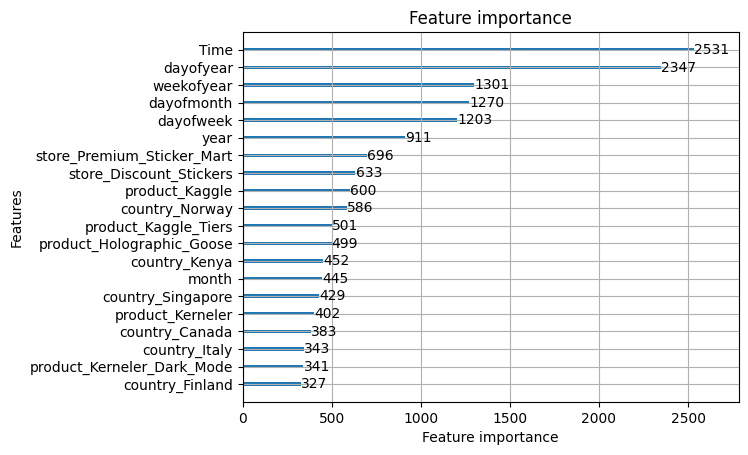

In [92]:
lgb.plot_importance(model_lgb, max_num_features=20, importance_type='split')

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

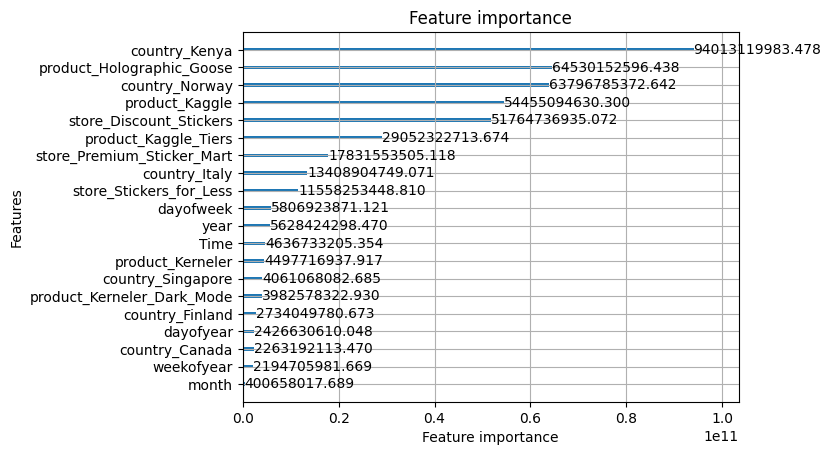

In [93]:
lgb.plot_importance(model_lgb, max_num_features=20, importance_type='gain')

In [94]:
import shap

SAMPLE_SIZE = 5000
X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)

explainer_lgb = shap.TreeExplainer(model_lgb)
shap_values_lgb = explainer_lgb.shap_values(X_train_sample)

shap_lgb = pd.DataFrame({
    'feature': X_train_sample.columns,
    'mean_abs_shap': np.abs(shap_values_lgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_lgb['pct'] = shap_lgb['mean_abs_shap'] / shap_lgb['mean_abs_shap'].sum() * 100

print(shap_lgb)

# Flag features below a threshold as candidates for removal
UMBRAL_PCT = 0.5  # adjust as needed

candidatas_a_eliminar = shap_lgb[shap_lgb['pct'] < UMBRAL_PCT]['feature'].tolist()
print(f"\nCandidate features to drop (< {UMBRAL_PCT}% of total importance):")
print(candidatas_a_eliminar)

                       feature  mean_abs_shap        pct
0                country_Kenya     197.423776  14.811968
1               country_Norway     186.896342  14.022134
2    product_Holographic Goose     179.548328  13.470840
3               product_Kaggle     155.538492  11.669472
4      store_Discount Stickers     150.136524  11.264182
5         product_Kaggle Tiers      97.289053   7.299234
6   store_Premium Sticker Mart      85.317323   6.401040
7                country_Italy      49.858055   3.740664
8                    dayofweek      46.694648   3.503325
9      store_Stickers for Less      32.605259   2.446251
10                        Time      27.447176   2.059259
11            product_Kerneler      27.082211   2.031877
12                        year      27.074374   2.031289
13           country_Singapore      22.247340   1.669135
14                   dayofyear      11.076461   0.831025
15  product_Kerneler Dark Mode      10.924962   0.819659
16                  weekofyear 

In [95]:
# Interaction values (more expensive than regular SHAP — use a smaller sample)
SAMPLE_SIZE_INTERACTION = 500
X_interaction_sample = X_train.sample(n=SAMPLE_SIZE_INTERACTION, random_state=42)

shap_interaction_values = explainer_lgb.shap_interaction_values(X_interaction_sample)

# Average absolute interaction strength between every pair of features
interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

interaction_df = pd.DataFrame(
    interaction_matrix, 
    index=X_interaction_sample.columns, 
    columns=X_interaction_sample.columns
)

# Extract the top interacting pairs (excluding the diagonal, which is each feature's own effect)
np.fill_diagonal(interaction_df.values, 0)

top_interactions = (
    interaction_df.where(np.triu(np.ones(interaction_df.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
    .head(20)
)

print("Top 20 feature interactions:")
print(top_interactions)

Top 20 feature interactions:
country_Norway              product_Holographic Goose     23.396952
                            store_Discount Stickers       23.390417
country_Kenya               product_Holographic Goose     21.693889
                            product_Kaggle                21.597196
                            store_Discount Stickers       20.470264
country_Norway              product_Kaggle                17.690114
store_Discount Stickers     product_Holographic Goose     17.285151
                            product_Kaggle                15.955958
country_Kenya               product_Kaggle Tiers          14.237397
product_Kaggle              product_Kaggle Tiers          12.977137
product_Holographic Goose   product_Kaggle                12.348184
country_Kenya               store_Premium Sticker Mart    12.284379
store_Premium Sticker Mart  store_Stickers for Less       10.613219
country_Norway              product_Kaggle Tiers          10.435933
year               

In [96]:
# Save dataframes
X_train_reduced = X_train.drop(columns=['quarter', 'dayofmonth', 'month']).copy()
X_test_reduced = X_test.drop(columns=['quarter', 'dayofmonth', 'month']).copy()

X_train_reduced.to_parquet(f'{Output_directory}X_train_reduced.parquet')
X_test_reduced.to_parquet(f'{Output_directory}X_test_reduced.parquet')

In [97]:
# LightGBM reduced
def objective_lgb(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbosity': -1,
    }
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train_reduced)):
        X_tr, X_va = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**param)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        rmse = np.sqrt(mean_squared_error(y_va, pred))
        fold_scores.append(rmse)

        trial.report(np.mean(fold_scores), step=fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_lgb_reduced = optuna.create_study(sampler=sampler, direction='minimize', pruner=pruner)
study_lgb_reduced.optimize(objective_lgb, n_trials=200, callbacks=[partial(early_stopping, patience=60)])
print(f"LightGBM best parameters: {study_lgb_reduced.best_params}")

# saves the study
joblib.dump(study_lgb_reduced, f'{Output_directory}study_lgb_reduced.pkl')


[I 2026-08-28 10:29:49,125] A new study created in memory with name: no-name-bac2f4b1-8607-403a-b517-26446f93ea10
[I 2026-08-28 10:30:05,445] Trial 0 finished with value: 107.46603636643604 and parameters: {'n_estimators': 437, 'max_depth': 12, 'num_leaves': 115, 'learning_rate': 0.07661100707771368, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 2.9152036385288193e-08, 'reg_lambda': 0.08499808989182997}. Best is trial 0 with value: 107.46603636643604.
[I 2026-08-28 10:30:16,323] Trial 1 finished with value: 110.2742651350389 and parameters: {'n_estimators': 641, 'max_depth': 10, 'num_leaves': 22, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 2.8483918709107956e-07, 'reg_lambda': 2.9324868872723725e-07}. Best is trial 0 with value: 107.46603636643604.
[I 2026-08-28 10:30:30,650] Trial 2 finished with value: 106.37262935491592 and parameters: {'n_estimators': 374, 'max_dept

LightGBM best parameters: {'n_estimators': 965, 'max_depth': 12, 'num_leaves': 74, 'learning_rate': 0.014286771885417658, 'subsample': 0.868856256358157, 'colsample_bytree': 0.6106840015307822, 'reg_alpha': 0.05689835852211172, 'reg_lambda': 0.0011077082932146143}


['/kaggle/working/study_lgb_reduced.pkl']

In [98]:
#Load study 
#study_lgb_reduced = joblib.load('/kaggle/input/datasets/davibaca/model-reduced/study_lgb_reduced.pkl')

In [99]:
print(f"Trials executed: {len(study_lgb_reduced.trials)}")
print(f"Best trial: {study_lgb_reduced.best_trial.number}")
print(f"Best RMSE: {study_lgb_reduced.best_value:.4f}")
print(f"Best parameters: {study_lgb_reduced.best_params}")

Trials executed: 200
Best trial: 179
Best RMSE: 103.9502
Best parameters: {'n_estimators': 965, 'max_depth': 12, 'num_leaves': 74, 'learning_rate': 0.014286771885417658, 'subsample': 0.868856256358157, 'colsample_bytree': 0.6106840015307822, 'reg_alpha': 0.05689835852211172, 'reg_lambda': 0.0011077082932146143}


In [100]:
df_trials_lgb_reduced = study_lgb_reduced.trials_dataframe()
print(df_trials_lgb_reduced[['number', 'value','state']].tail(15))

     number       value     state
185     185  104.362427  COMPLETE
186     186  105.146071    PRUNED
187     187  104.853842    PRUNED
188     188  104.866333    PRUNED
189     189  105.877884    PRUNED
190     190  104.174529  COMPLETE
191     191  104.787823    PRUNED
192     192  104.027981  COMPLETE
193     193  104.007970  COMPLETE
194     194  104.077735  COMPLETE
195     195  104.183988  COMPLETE
196     196  104.689578  COMPLETE
197     197  104.114116  COMPLETE
198     198  104.422221  COMPLETE
199     199  104.789217  COMPLETE


In [101]:
vis.plot_optimization_history(study_lgb_reduced).show()
vis.plot_param_importances(study_lgb_reduced).show()

In [102]:
# from sklearn.preprocessing import StandardScaler
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping 
# from tensorflow.keras.optimizers import Adam

# X_train_dl = X_train.copy()
# X_test_dl = X_test.copy()

# X_train_dl['month_sin'] = np.sin(2 * np.pi * X_train_dl['month'] / 12)
# X_train_dl['month_cos'] = np.cos(2 * np.pi * X_train_dl['month'] / 12)

# X_train_dl['dayofweek_sin'] = np.sin(2 * np.pi * X_train_dl['dayofweek'] / 7)
# X_train_dl['dayofweek_cos'] = np.cos(2 * np.pi * X_train_dl['dayofweek'] / 7)

# X_train_dl['dayofyear_sin'] = np.sin(2 * np.pi * X_train_dl['dayofyear'] / 365)
# X_train_dl['dayofyear_cos'] = np.cos(2 * np.pi * X_train_dl['dayofyear'] / 365)

# X_train_dl['weekofyear_sin'] = np.sin(2 * np.pi * X_train_dl['weekofyear'] / 52)
# X_train_dl['weekofyear_cos'] = np.cos(2 * np.pi * X_train_dl['weekofyear'] / 52)

# X_train_dl = X_train_dl.drop(columns=['month', 'dayofweek', 'dayofyear', 'weekofyear'])

# X_test_dl['month_sin'] = np.sin(2 * np.pi * X_test_dl['month'] / 12)
# X_test_dl['month_cos'] = np.cos(2 * np.pi * X_test_dl['month'] / 12)

# X_test_dl['dayofweek_sin'] = np.sin(2 * np.pi * X_test_dl['dayofweek'] / 7)
# X_test_dl['dayofweek_cos'] = np.cos(2 * np.pi * X_test_dl['dayofweek'] / 7)

# X_test_dl['dayofyear_sin'] = np.sin(2 * np.pi * X_test_dl['dayofyear'] / 365)
# X_test_dl['dayofyear_cos'] = np.cos(2 * np.pi * X_test_dl['dayofyear'] / 365)

# X_test_dl['weekofyear_sin'] = np.sin(2 * np.pi * X_test_dl['weekofyear'] / 52)
# X_test_dl['weekofyear_cos'] = np.cos(2 * np.pi * X_test_dl['weekofyear'] / 52)

# X_test_dl = X_test_dl.drop(columns=['month', 'dayofweek', 'dayofyear', 'weekofyear'])

# split_date = '2014-01-02'

# X_train_dl[['date', 'num_sold']] = df_merged.loc[X_train_dl.index, ['date', 'num_sold']]
# X_train_cat[['date', 'num_sold']] = df_merged.loc[X_train_cat.index, ['date', 'num_sold']]
# id_test = df_merged.loc[X_test.index, 'id'].values

# X_train_dl = X_train_dl.sort_values('date')

# train_final = X_train_dl[X_train_dl['date'] < split_date]
# val = X_train_dl[X_train_dl['date'] >= split_date]

# y_train = train_final['num_sold']
# y_val = val['num_sold']

# X_train_final = train_final.drop(columns=['num_sold', 'date'])
# X_val = val.drop(columns=['num_sold', 'date'])


# scaler_mlp = StandardScaler()
# X_train_scaled = scaler_mlp.fit_transform(X_train_final)
# X_val_scaled = scaler_mlp.transform(X_val)
# X_test_scaled = scaler_mlp.transform(X_test_dl)

# model_mlp = Sequential([
#     Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
#     BatchNormalization(),
#     Dropout(0.4),
#     Dense(128, activation='relu'),
#     BatchNormalization(),
#     Dropout(0.4),
#     Dense(64, activation='relu'),
#     Dropout(0.3),
#     Dense(1)
# ])

# model_mlp.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

# checkpoint_mlp = ModelCheckpoint(f'{Output_directory}best_mlp.keras', monitor='val_loss', save_best_only=True)
# early_stop_mlp = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# history_mlp = model_mlp.fit(
#     X_train_scaled, y_train,
#     validation_data=(X_val_scaled, y_val),
#     epochs=100,
#     batch_size=256,
#     callbacks=[checkpoint_mlp, early_stop_mlp],
#     verbose=1
# )

# pred_val_mlp = model_mlp.predict(X_val_scaled).flatten()
# rmse_mlp = np.sqrt(mean_squared_error(y_val, pred_val_mlp))
# print(f"MLP RMSE (val): {rmse_mlp:.4f}")

# pred_test_mlp = model_mlp.predict(X_test_scaled).flatten()
# joblib.dump(pred_val_mlp, f'{Output_directory}pred_val_mlp.pkl')

# submission_mlp = pd.DataFrame({'id': id_test, 'num_sold': pred_test_mlp})
# submission_mlp.to_csv(f'{Output_directory}submission_mlp.csv', index=False)

In [103]:
# def display_training_curves(training, validation, title, subplot):
#     if subplot % 10 == 1:
#         plt.subplots(figsize=(12, 5), facecolor='#F0F0F0')
#         plt.tight_layout()
#     ax = plt.subplot(subplot)
#     ax.set_facecolor('#F8F8F8')
#     ax.plot(training)
#     ax.plot(validation)
#     ax.set_title('Model ' + title)
#     ax.set_ylabel(title)
#     ax.set_xlabel('epoch')
#     ax.legend(['train', 'valid.'])

# display_training_curves(
#     history_mlp.history['loss'],
#     history_mlp.history['val_loss'],
#     'loss (MSE)',
#     121,
# )
# display_training_curves(
#     history_mlp.history['mae'],
#     history_mlp.history['val_mae'],
#     'MAE',
#     122,
# )
# plt.show()

In [104]:
# models = {
#     'LightGBM': model_lgb,      
#     'XGBoost': model_xgb,
#     'GradientBoosting': model_gb,
#     'RandomForest': model_rf,
#     'ExtraTrees': model_et
# }

# predictions = {}

# for name, model in models.items():
#     predictions[name] = model.predict(X_test)

# df_preds = pd.DataFrame(predictions)

# #add MLP
# df_preds['MLP'] = pred_test_mlp

# corr_matrix = df_preds.corr()

# print(corr_matrix.round(3))

In [105]:
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
# plt.show()